# Aspect-Based Sentiment Analysis — Comparaison des modèles

## Overview

Dans ce projet, nous analysons des avis Amazon (catégorie *Baby Products*) **au-delà d'une note globale** : pour chaque phrase et chaque aspect détecté (prix, qualité, sécurité, etc.), nous prédisons un sentiment **binaire** (`positive` / `negative`).

Deux architectures Deep Learning en PyTorch ont été entraînées sur le **même split** (`data_splits/`) :

| Modèle | Rôle | Fichier |
|--------|------|---------|
| **Bi-LSTM baseline** | Référence « from scratch » (embeddings + LSTM) | `src/train_baseline.py` |
| **BERT fine-tuné** | Modèle avancé (transfert + attention) | `src/train_bert.py` |

### Objectif de ce notebook

1. **Présenter** les concepts clés des deux modèles  
2. **Comparer** les différences conceptuelles et leurs implications en programmation  
3. **Évaluer** les métriques sur le jeu de test  
4. **Comparer** les résultats pour choisir / justifier le modèle de production (démo Streamlit)

> Style inspiré du notebook pédagogique [first-neural-network-from-scratch](lien_vers_le_cours)

## 1. Setup et chemins

On charge les métriques déjà produites par les scripts d'entraînement (`test_metrics.json`) et, si disponibles, les courbes et l'analyse d'erreurs.

In [1]:
from pathlib import Path
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Racine du repo = parent de "models analysis"
REPO_ROOT = Path("../..").resolve()
BASELINE_DIR = REPO_ROOT / "outputs" / "baseline"
BERT_DIR = REPO_ROOT / "outputs" / "bert"
ERROR_DIR = REPO_ROOT / "outputs" / "error_analysis"

print(f"REPO_ROOT     : {REPO_ROOT}")
print(f"Baseline dir  : {BASELINE_DIR}  exists={BASELINE_DIR.exists()}")
print(f"BERT dir      : {BERT_DIR}  exists={BERT_DIR.exists()}")
print(f"Error analysis: {ERROR_DIR}  exists={ERROR_DIR.exists()}")

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = [10, 5]
plt.rcParams["font.size"] = 12

REPO_ROOT     : C:\Users\karl\OneDrive\Documents\Data Engineer\Projets\Master Data Engineering\Machine-learning-project-lionel-karl
Baseline dir  : C:\Users\karl\OneDrive\Documents\Data Engineer\Projets\Master Data Engineering\Machine-learning-project-lionel-karl\outputs\baseline  exists=True
BERT dir      : C:\Users\karl\OneDrive\Documents\Data Engineer\Projets\Master Data Engineering\Machine-learning-project-lionel-karl\outputs\bert  exists=True
Error analysis: C:\Users\karl\OneDrive\Documents\Data Engineer\Projets\Master Data Engineering\Machine-learning-project-lionel-karl\outputs\error_analysis  exists=True


## 2. Présentation des deux modèles — concepts clés

### 2.1 Formulation commune de la tâche (ABSA)

Les deux modèles résolvent **la même tâche** :

$$
(aspect, phrase) \mapsto sentiment \in \{\text{negative},\ \text{positive}\}
$$

Il est important de comprendre que ce n'est pas un simple sentiment global, sans l'aspect en entrée, on ne pourrait pas distinguer pour la phrase suivante :
*« the price is great but the safety strap is flimsy »* → `price=positive`, `safety=negative`.

---

### 2.2 Bi-LSTM baseline — concepts clés

| Concept | Rôle dans notre baseline |
|---------|--------------------------|
| **Embedding de mots** | Chaque token devient un vecteur appris *from scratch* (vocabulaire construit sur le train uniquement) |
| **Bi-LSTM** | Lit la phrase dans les deux sens (passé + futur) pour capturer le contexte local |
| **Embedding d'aspect** | Un vecteur discret par catégorie d'aspect (prix, qualité, …) |
| **Concaténation tardive** | `[état Bi-LSTM ; embedding aspect]` puis MLP → 2 classes |
| **Boucle d'entraînement manuelle** | `zero_grad → forward → loss → backward → step` |

**Idée centrale** : la phrase et l'aspect sont encodés **séparément**, puis fusionnés **juste avant** la classification. Le LSTM ne « voit » jamais l'aspect pendant qu'il lit les mots.

```
tokens ──► Embedding ──► Bi-LSTM ──► h_sentence ─┐
                                                  ├─► concat ──► MLP ──► logits
aspect ──► Embedding ─────────────────────────────┘
```

---

### 2.3 BERT fine-tuné — concepts clés

| Concept | Rôle dans notre BERT |
|---------|----------------------|
| **Pré-entraînement** | BERT a déjà appris le langage (MLM / NSP) sur un large corpus |
| **Fine-tuning** | On met à jour tous les poids + une tête de classification nouvelle |
| **BERT-SPC (Sentence Pair Classification)** | Entrée = `[CLS] aspect [SEP] phrase [SEP]` |
| **Self-attention** | Chaque mot peut directement « regarder » l'aspect dès les premières couches |
| **Tokenisation WordPiece** | Sous-mots gérés par le tokenizer HF (pas notre vocab LSTM) |
| **Scheduler + warmup** | Learning rate bas (`2e-5`), AdamW, warmup (standard du transfert) |

**Idée centrale** : l'aspect et la phrase forment une seule séquence. L'attention joint les deux signaux tôt dans le réseau (approche BERT-SPC, Sun et al., 2019).

```
[CLS] aspect [SEP] phrase [SEP]
        │
        ▼
   BERT (12 couches, attention)
        │
     vecteur [CLS]
        │
   Linear(num_labels=2) ──► logits
```

## 3. Différences conceptuelles et implications en programmation

Nos deux modèles pour un même problème et une même tâche ABSA, vont avoir deux façons de représenter et d'apprendre différentes.

### 3.1 Tableau de comparaison

| Dimension | Bi-LSTM | BERT |
|-----------|---------|------|
| **Représentation du texte** | Tokens maison + IDs (`token_ids` de `prep_data.py`) | WordPiece Hugging Face (`sentence` brut) |
| **Représentation de l'aspect** | Embedding catégoriel séparé | Texte de l'aspect dans la paire |
| **Interaction aspect ↔ phrase** | Tardive (concat) | Précoce (attention) |
| **Connaissance préalable** | Aucune (appris sur nos avis) | Transfert depuis `bert-base-uncased` |
| **Paramètres** | ~quelques centaines de k | ~110 M |
| **Données nécessaires** | Plus sensible au volume / bruit des pseudo-labels | Plus robuste grâce au pré-entraînement |
| **Coût compute** | CPU OK | GPU fortement recommandé |
| **Risque de sur-apprentissage** | Moyen (petit modèle) | Élevé si trop d'epochs (d'où early stopping strict) |

### 3.2 Ce que cela change dans le code

| Étape pipeline | Bi-LSTM | BERT |
|----------------|---------|------|
| **Prep données** | Vocabulaire + `token_ids` obligatoires | Texte nettoyé suffit |
| **Dataset** | `(token_ids, aspect_id, label)` + padding / `pack_padded_sequence` | Tokeniser la *paire* en batch |
| **Modèle** | Classe `nn.Module` écrite à la main (`BiLSTMABSA`) | `AutoModelForSequenceClassification` + `load_state_dict` |
| **Loss** | `CrossEntropyLoss` | Idem (intégrée dans HF si `labels=` fournis) |
| **Optimiseur** | `Adam` ~`1e-3` | `AdamW` ~`2e-5` + scheduler |
| **Boucle** | Identique conceptuellement (`train` / `eval`, early stopping sur F1 val) | Idem, + gradient clipping |
| **Sauvegarde** | `best_model.pt` (state + mappings) | `best_model_state.pt` + dossier `tokenizer/` |
| **Inférence démo** | Possible mais non branché dans Streamlit | Branché dans `app.py` (synthèse corpus) |

### 3.3 Lien avec le cours sur PyTorch et Numpy

*NumPy = comprendre les gradients / PyTorch = automatiser sans perdre le contrôle*.

Ici la même logique s'applique à deux niveaux :

1. **Baseline Bi-LSTM** = on *contrôle* embeddings, LSTM, tête MLP, boucle d'entraînement → idéal pour la défense orale.  
2. **BERT** = on *réutilise* un encodeur pré-entraîné et on se concentre sur la reformulation de la tâche (paire aspect–phrase) et le protocole de fine-tuning.

## 4. Chargement des métriques de test

Les scripts d'entraînement ont déjà évalué le **meilleur checkpoint** (selon F1 macro validation) sur le **même test set**.

In [2]:
def load_metrics(path: Path) -> dict:
    with open(path, encoding="utf-8") as f:
        return json.load(f)


baseline_metrics = load_metrics(BASELINE_DIR / "test_metrics.json")
bert_metrics = load_metrics(BERT_DIR / "test_metrics.json")

summary = pd.DataFrame(
    [
        {
            "model": "Bi-LSTM",
            "accuracy": baseline_metrics["accuracy"],
            "macro_precision": baseline_metrics["macro_precision"],
            "macro_recall": baseline_metrics["macro_recall"],
            "macro_f1": baseline_metrics["macro_f1"],
        },
        {
            "model": "BERT",
            "accuracy": bert_metrics["accuracy"],
            "macro_precision": bert_metrics["macro_precision"],
            "macro_recall": bert_metrics["macro_recall"],
            "macro_f1": bert_metrics["macro_f1"],
        },
    ]
).set_index("model")

print("=== Métriques agrégées (test set) ===")
display(summary.round(4))

delta = summary.loc["BERT"] - summary.loc["Bi-LSTM"]
print("\nGain BERT − Bi-LSTM :")
display(delta.round(4).to_frame("delta"))

=== Métriques agrégées (test set) ===


,accuracy,macro_precision,macro_recall,macro_f1
model,,,,
Bi-LSTM,0.8179,0.8013,0.8046,0.8029
BERT,0.9293,0.9266,0.9184,0.9222



Gain BERT − Bi-LSTM :


,delta
accuracy,0.1113
macro_precision,0.1253
macro_recall,0.1137
macro_f1,0.1194


## 5. Évaluation détaillée & classification

Le **macro-F1** donne le même poids à chaque classe. C'est important ici car `positive` est majoritaire dans les avis et donc l'accuracy seule pourrait masquer une faiblesse sur `negative`.

In [3]:
def parse_classification_report(report_text: str) -> pd.DataFrame:
    """Parse le classification_report texte stocké dans test_metrics.json."""
    rows = []
    for line in report_text.strip().splitlines():
        line = line.strip()
        if not line or line.startswith("precision") or set(line) <= set("- "):
            continue
        parts = re.split(r"\s+", line)
        # formats: "negative 0.74 0.76 0.75 1989" ou "accuracy 0.82 5569"
        if parts[0] == "accuracy":
            rows.append(
                {
                    "label": "accuracy",
                    "precision": np.nan,
                    "recall": np.nan,
                    "f1-score": float(parts[1]),
                    "support": int(parts[2]),
                }
            )
        elif parts[0] in {"macro", "weighted"}:
            rows.append(
                {
                    "label": f"{parts[0]} avg",
                    "precision": float(parts[2]),
                    "recall": float(parts[3]),
                    "f1-score": float(parts[4]),
                    "support": int(parts[5]),
                }
            )
        else:
            rows.append(
                {
                    "label": parts[0],
                    "precision": float(parts[1]),
                    "recall": float(parts[2]),
                    "f1-score": float(parts[3]),
                    "support": int(parts[4]),
                }
            )
    return pd.DataFrame(rows).set_index("label")


print("=== Bi-LSTM — classification report ===")
print(baseline_metrics["classification_report"])
baseline_report = parse_classification_report(baseline_metrics["classification_report"])

print("=== BERT — classification report ===")
print(bert_metrics["classification_report"])
bert_report = parse_classification_report(bert_metrics["classification_report"])

=== Bi-LSTM — classification report ===
              precision    recall  f1-score   support

    negative       0.74      0.76      0.75      1989
    positive       0.86      0.85      0.86      3580

    accuracy                           0.82      5569
   macro avg       0.80      0.80      0.80      5569
weighted avg       0.82      0.82      0.82      5569

=== BERT — classification report ===
              precision    recall  f1-score   support

    negative       0.92      0.88      0.90      1989
    positive       0.94      0.96      0.95      3580

    accuracy                           0.93      5569
   macro avg       0.93      0.92      0.92      5569
weighted avg       0.93      0.93      0.93      5569



In [4]:
# Focus sur les classes negative / positive
class_labels = [c for c in ["negative", "positive"] if c in baseline_report.index]

per_class = pd.concat(
    {
        "Bi-LSTM": baseline_report.loc[class_labels, ["precision", "recall", "f1-score"]],
        "BERT": bert_report.loc[class_labels, ["precision", "recall", "f1-score"]],
    },
    axis=1,
)

print("Métriques par classe (test)")
display(per_class.round(3))

support = baseline_report.loc[class_labels, ["support"]].rename(columns={"support": "n_test"})
display(support)

Métriques par classe (test)


Bi-LSTM                      BERT                
         precision recall f1-score precision recall f1-score
label                                                       
negative      0.74   0.76     0.75      0.92   0.88     0.90
positive      0.86   0.85     0.86      0.94   0.96     0.95

,n_test
label,
negative,1989
positive,3580


## 6. Comparaison visuelle des résultats

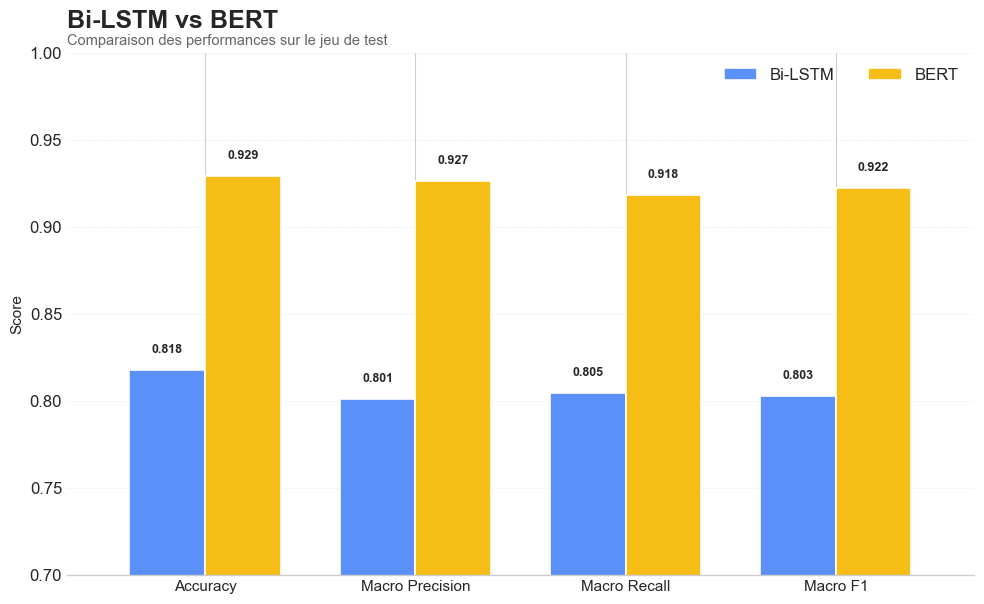

In [10]:
metrics_to_plot = [
    "accuracy",
    "macro_precision",
    "macro_recall",
    "macro_f1"
]

plot_df = summary[metrics_to_plot].T

plot_df.index = [
    "Accuracy",
    "Macro Precision",
    "Macro Recall",
    "Macro F1"
]

fig, ax = plt.subplots(figsize=(10, 6.2))

x = np.arange(len(plot_df))
width = 0.36

# Couleurs sobres et modernes
c_lstm = "#5B8FF9"
c_bert = "#F6BD16"

bars1 = ax.bar(
    x - width / 2,
    plot_df.iloc[:, 0],
    width,
    label="Bi-LSTM",
    color=c_lstm,
    edgecolor="white",
    linewidth=1.2
)

bars2 = ax.bar(
    x + width / 2,
    plot_df.iloc[:, 1],
    width,
    label="BERT",
    color=c_bert,
    edgecolor="white",
    linewidth=1.2
)

# Axe Y
ax.set_ylim(0.70, 1.00)
ax.set_yticks(np.arange(0.70, 1.01, 0.05))
ax.set_ylabel("Score", fontsize=11)

# Axe X
ax.set_xticks(x)
ax.set_xticklabels(plot_df.index, fontsize=11)

# Grille
ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.7,
    alpha=0.25
)
ax.set_axisbelow(True)

# Nettoyage
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

# Titre
ax.set_title(
    "Bi-LSTM vs BERT",
    fontsize=18,
    fontweight="bold",
    loc="left",
    pad=18
)

ax.text(
    0,
    1.015,
    "Comparaison des performances sur le jeu de test",
    transform=ax.transAxes,
    fontsize=10.5,
    color="#666666"
)

# Légende
ax.legend(
    frameon=False,
    ncol=2,
    loc="upper right"
)

# Valeurs
for bars in [bars1, bars2]:
    for bar in bars:
        value = bar.get_height()

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value + 0.008,
            f"{value:.3f}",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold"
        )

# Petite marge horizontale
ax.margins(x=0.08)

plt.tight_layout()
plt.show()

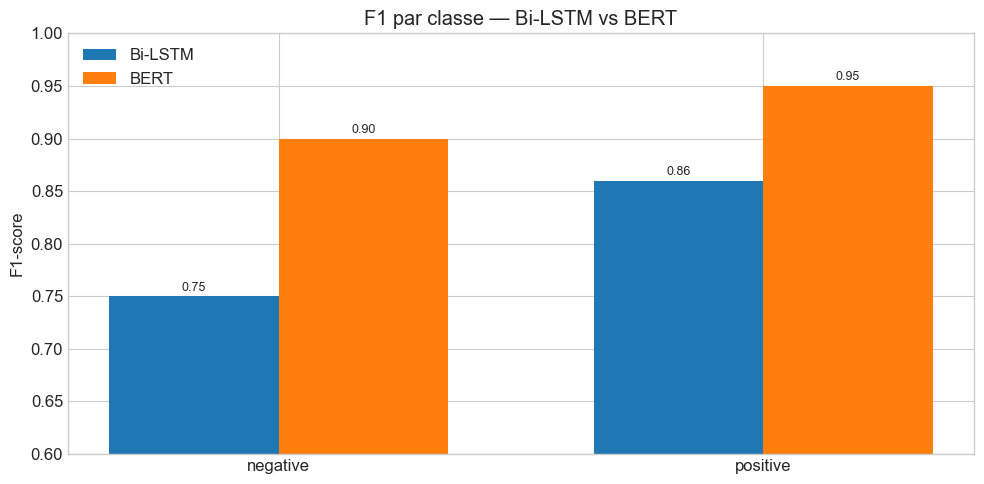

In [6]:
# F1 par classe
fig, ax = plt.subplots()
x = np.arange(len(class_labels))
width = 0.35

bilstm_f1 = baseline_report.loc[class_labels, "f1-score"].values
bert_f1 = bert_report.loc[class_labels, "f1-score"].values

bars1 = ax.bar(x - width / 2, bilstm_f1, width, label="Bi-LSTM")
bars2 = ax.bar(x + width / 2, bert_f1, width, label="BERT")

ax.set_xticks(x)
ax.set_xticklabels(class_labels)
ax.set_ylim(0.6, 1.0)
ax.set_ylabel("F1-score")
ax.set_title("F1 par classe — Bi-LSTM vs BERT")
ax.legend()
ax.bar_label(bars1, fmt="%.2f", fontsize=9, padding=2)
ax.bar_label(bars2, fmt="%.2f", fontsize=9, padding=2)
plt.tight_layout()
plt.show()

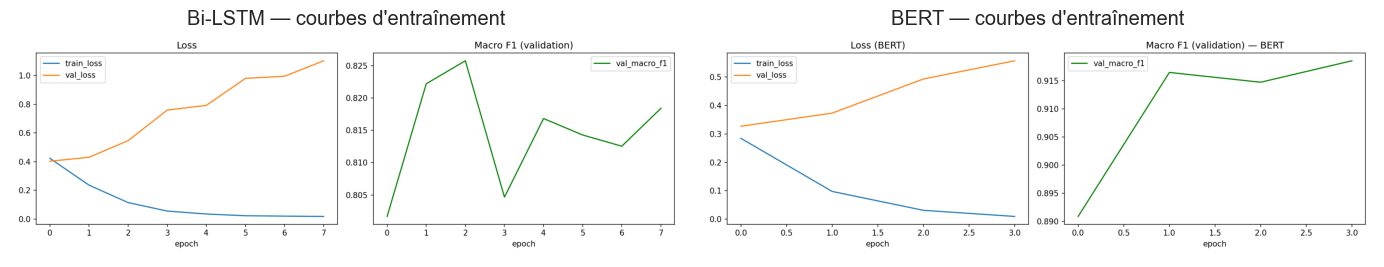

In [12]:
# Courbes d'entraînement sauvegardées par les scripts
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, path, title in [
    (axes[0], BASELINE_DIR / "training_curves.png", "Bi-LSTM — courbes d'entraînement"),
    (axes[1], BERT_DIR / "training_curves.png", "BERT — courbes d'entraînement"),
]:
    if path.exists():
        img = plt.imread(path)
        ax.imshow(img)
        ax.axis("off")
        ax.set_title(title)
    else:
        ax.text(0.5, 0.5, f"Fichier manquant:\n{path.name}", ha="center", va="center")
        ax.axis("off")

plt.tight_layout()
plt.show()

## 7. Analyse d'erreurs comparative (si disponible)

Le script `src/error_analysis.py` croise les prédictions des deux modèles sur le test set et catégorise :

- `bert_fixes_baseline_error` ──► BERT corrige une erreur du LSTM (**preuve de valeur ajoutée**)
- `both_wrong` ──► les deux se trompent (**souvent label bruit / phrase ambiguë**)
- `bert_introduces_new_error` ──► LSTM avait raison, BERT se trompe

Exemples analysés : 5569


,n,pct
category,,
both_correct,4406,79.1
bert_fixes_baseline_error,769,13.8
both_wrong,245,4.4
bert_introduces_new_error,149,2.7


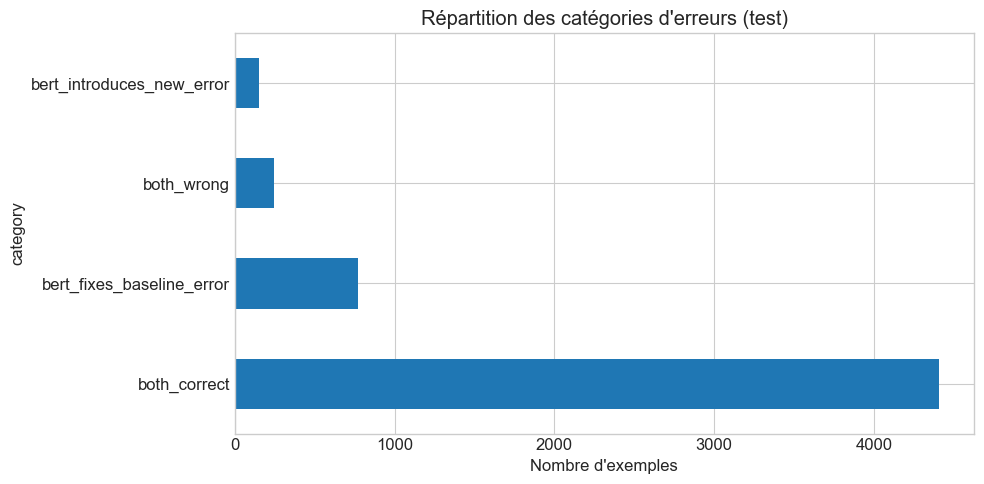


Exemples : BERT corrige le Bi-LSTM :


,aspect,sentence,true_label,baseline_pred,bert_pred
0,safety for babies and children,Providing a mat cover to place food on top all...,positive,negative,positive
1,"durability, washability and longevity","Wipe surface with damn cloth, it will help tre...",positive,negative,positive
2,"design, appearance and looks","Wipe surface with damn cloth, it will help tre...",positive,negative,positive
3,"ease of use, assembly and convenience",Removal is simple- peel and done! <br,negative,positive,negative
4,product quality and performance,Removal is simple- peel and done! <br,negative,positive,negative


In [8]:
cat_path = ERROR_DIR / "categorized_errors.csv"

if cat_path.exists():
    err = pd.read_csv(cat_path)
    counts = err["category"].value_counts()
    pct = (100 * counts / len(err)).round(1)

    overview = pd.DataFrame({"n": counts, "pct": pct})
    print(f"Exemples analysés : {len(err)}")
    display(overview)

    ax = counts.plot(kind="barh")
    ax.set_xlabel("Nombre d'exemples")
    ax.set_title("Répartition des catégories d'erreurs (test)")
    plt.tight_layout()
    plt.show()

    # Aperçu qualitatif : cas où BERT corrige le baseline
    fixes = err[err["category"] == "bert_fixes_baseline_error"].head(5)
    if not fixes.empty:
        print("\nExemples : BERT corrige le Bi-LSTM :")
        display(
            fixes[
                ["aspect", "sentence", "true_label", "baseline_pred", "bert_pred"]
            ].reset_index(drop=True)
        )
else:
    print(
        f"Pas de fichier {cat_path}.\n"
        "Lancez : python src/error_analysis.py "
        "--baseline-dir models/baseline --bert-dir models/bert --output-dir outputs/error_analysis"
    )

In [9]:
# Taux d'erreur BERT par aspect / négation
aspect_err = ERROR_DIR / "error_rate_by_aspect.csv"
neg_err = ERROR_DIR / "negation_analysis.csv"

if aspect_err.exists():
    by_aspect = pd.read_csv(aspect_err)
    # colonnes possibles selon export
    print("=== Taux d'erreur BERT par aspect (extrait) ===")
    display(by_aspect.head(10))

if neg_err.exists():
    by_neg = pd.read_csv(neg_err)
    print("=== Erreur BERT vs marqueurs de négation/contraste ===")
    display(by_neg)

=== Taux d'erreur BERT par aspect (extrait) ===


,aspect,taux_erreur_bert,n_exemples
0,"ease of use, assembly and convenience",0.096531,663
1,"size, dimensions and fit",0.089606,279
2,safety for babies and children,0.082418,546
3,"durability, washability and longevity",0.080692,347
4,"price, cost and value for money",0.076923,299
5,product quality and performance,0.064914,1864
6,"design, appearance and looks",0.058275,858
7,"comfort, softness and texture",0.057878,622
8,customer service and seller support,0.026316,38
9,"packaging, shipping and delivery",0.018868,53


=== Erreur BERT vs marqueurs de négation/contraste ===


,has_negation_marker,taux_erreur_bert,n_exemples
0,False,0.061858,4187
1,True,0.097685,1382


## 8. Synthèse et recommandations

### 8.1 Ce que disent les chiffres (test set)

| Modèle | Accuracy | Macro-F1 | Lecture |
|--------|----------|----------|---------|
| Bi-LSTM | ~0.82 | ~0.80 | Baseline solide, compréhensible ligne à ligne |
| BERT | ~0.93 | ~0.92 | Gain net grâce au pré-entraînement + interaction aspect–phrase |

BERT améliore à la fois `positive` **et** `negative` (voir F1 par classe), ce qui indique que le gain n'est pas seulement un biais vers la classe majoritaire.

### 8.2 Ce que cela implique pour le projet

1. **Baseline Bi-LSTM** : indispensable pédagogiquement (boucle PyTorch, embeddings, Bi-LSTM) et comme référence quantitative.  
2. **BERT** : modèle à déployer dans la démo Streamlit (`app.py`) pour la synthèse d'un corpus d'avis.  
3. **Limites communes** : labels issus d'un pipeline zero-shot + SST-2 (bruit possible, qualité des labels utilisés pour entraîner ou évaluer le modèle peut être imparfaite, parce qu'ils ne proviennent pas nécessairement d'une annotation humaine spécifique à ton problème d'ABSA), les phrases mixtes (*cute but … fails*) restent difficiles.  
4. **Pistes d'amélioration** : segmentation plus fine sur *but/however*, détection d'aspects plus riche (NLI) en inférence, calibration des confiances.